# Bayesian Optimisation: Finding Compounds That Meet a Spec

In materials and formulation work, the question is rarely "what's the maximum?" It's usually **"which candidates meet the specification?"**, answered with as few experiments as possible, run in batches. This notebook frames boiling-point prediction that way:

- **Spec:** a boiling point of **453–473 K** (180–200 °C), a typical range for a high-boiling solvent.
- **Candidates:** the 1,251 compounds with *measured* boiling points (after the label audit in `Label_Audit.ipynb`). Each "experiment" reveals one compound's boiling point.
- **Campaign:** 10 random starting experiments, then **batches of 5**, up to 150 experiments (12% of the pool).
- **Success:** the number of in-spec compounds found per experiment, averaged over 20 random starts.

Maximising the boiling point would be a poor test: sorting by molecular weight nearly solves it. A window in the middle of the range is harder, and closer to real specifications.

The computation runs in `scripts/run_bo_campaign.py` (~3 minutes on 9 cores); this notebook loads its results.

In [1]:
import sys
sys.path.insert(0, "src")
sys.path.insert(0, "scripts")

from boiling_point import bayes_opt, viz  # boiling_point first: loads xgboost before torch

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from run_feature_study import load_study_data
from run_bo_campaign import gp_features

LO, HI = 453.0, 473.0
df, feature_sets = load_study_data(audited=True)
in_spec = df["boiling_point_kelvin"].between(LO, HI)
results = pd.read_csv("results/bo_campaign.csv")
print(f"{len(df)} measured compounds; {in_spec.sum()} in spec ({in_spec.mean():.1%}); "
      f"GP features: {gp_features(feature_sets['curated (log)']).shape[1]}")

1251 measured compounds; 151 in spec (12.1%); GP features: 19


## Why a simple rule can't find them

Boiling point tracks molecular weight, but hydrogen bonding shifts it enormously: an OH group adds roughly as much as five or six extra CH₂ groups. So in-spec compounds range from small diols to large alkanes:

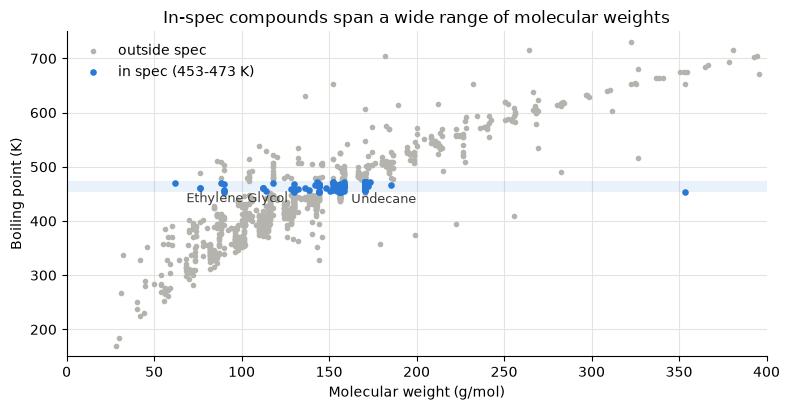

,compounds,min_mw,max_mw
family,,,
alkane,88,156.0,170.0
alcohol/phenol,42,62.0,158.0
alkene/alkyne,14,136.0,154.0
amine,7,143.0,354.0


In [2]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.axhspan(LO, HI, color="#2a78d6", alpha=0.10, linewidth=0)
ax.scatter(df.loc[~in_spec, "mw"], df.loc[~in_spec, "boiling_point_kelvin"], s=9, color="#b4b3ad",
           label="outside spec")
ax.scatter(df.loc[in_spec, "mw"], df.loc[in_spec, "boiling_point_kelvin"], s=14, color="#2a78d6",
           label=f"in spec ({LO:.0f}-{HI:.0f} K)")
for name in ["Ethylene Glycol", "Undecane"]:
    row = df[df["cmpdname"] == name]
    if len(row):
        ax.annotate(name, (row["mw"].iloc[0], row["boiling_point_kelvin"].iloc[0]), xytext=(8, -14),
                    textcoords="offset points", fontsize=9, color="#3a3a37")
ax.set_xlabel("Molecular weight (g/mol)")
ax.set_ylabel("Boiling point (K)")
ax.set_title("In-spec compounds span a wide range of molecular weights")
ax.set_xlim(0, 400)
ax.set_ylim(150, 750)
ax.grid(True, color="#e4e3dd", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

(df[in_spec].groupby("family")["mw"].agg(compounds="size", min_mw="min", max_mw="max").round(0)
 .sort_values("compounds", ascending=False))

## Strategies

All strategies start from the same 10 random experiments for a given seed, then choose batches of 5.

| Strategy | How it picks the next batch |
|---|---|
| **Random** | Uniformly at random |
| **Molecular-weight rule** | Fits boiling point ~ log(molecular weight) on the results so far; picks compounds predicted closest to the window centre |
| **Greedy GP** | Gaussian process on the curated RDKit descriptors; picks the compounds whose *predicted* boiling point is closest to the centre, ignoring uncertainty |
| **BO: probability in spec** | Same GP; picks the compounds with the highest probability of landing in the window, P(453 ≤ Tb ≤ 473). This naturally trades off "predicted near the window" against "uncertain, might be in the window". Each batch is built one pick at a time, updating the GP as if each pick returned its predicted value (the "kriging believer" trick). That reduces uncertainty near it, so the batch spreads out. |
| **BO: qLogEI toward target** | BoTorch's batch Monte Carlo `qLogExpectedImprovement` on the objective −\|Tb − 463 K\|, optimised jointly over the batch with `optimize_acqf_discrete` |

The GP is refitted after every batch (BoTorch `SingleTaskGP`, one length scale per feature, learned noise).

## Results

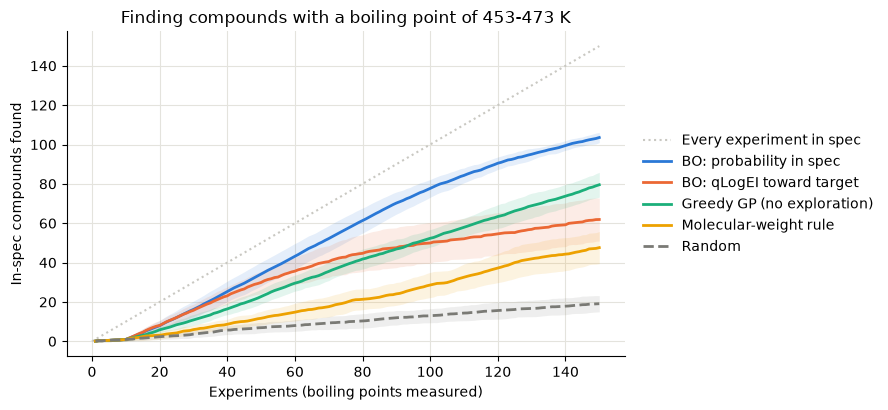

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.2))
viz.plot_bo_campaign(results, int(in_spec.sum()), ax=ax,
                     title=f"Finding compounds with a boiling point of {LO:.0f}-{HI:.0f} K")
plt.show()

In [4]:
at = results[results["experiment"].isin([50, 100, 150])].pivot_table(
    index="strategy", columns="experiment", values="hits", aggfunc=["mean", "std"]).round(1)
final = results[results["experiment"] == 150].pivot_table(index="seed", columns="strategy", values="hits")
at[("in-spec found at 150", "share of all")] = (final.mean() / in_spec.sum()).map("{:.0%}".format)
at[("vs random at 150", "×")] = (final.mean() / final["random"].mean()).round(1)
at[("probability-in-spec wins", "of 20 seeds")] = [
    "—" if s == "prob_in_spec" else f"{(final['prob_in_spec'] > final[s]).sum()}/20" for s in at.index]
at.sort_values(("mean", 150), ascending=False)

mean               std             in-spec found at 150  \
experiment       50   100    150   50   100   150         share of all   
strategy                                                                 
prob_in_spec   34.2  77.7  103.6  6.1   4.5   2.6                  69%   
greedy_gp      22.8  52.4   79.6  3.7   4.5   6.3                  53%   
qlogei_target  29.9  50.0   61.9  5.6  10.3  10.9                  41%   
mw_heuristic   11.7  28.6   47.6  3.5   6.4   8.2                  32%   
random          7.0  13.0   19.1  2.6   3.6   4.1                  13%   

              vs random at 150 probability-in-spec wins  
experiment                   ×              of 20 seeds  
strategy                                                 
prob_in_spec               5.4                        —  
greedy_gp                  4.2                    20/20  
qlogei_target              3.2                    20/20  
mw_heuristic               2.5                    20/20  
random                     1.0                    20/20

In [5]:
bayes_opt.experiments_to_reach(results, targets=(10, 25, 50))

,experiments to 10 hits,seeds reaching 10,experiments to 25 hits,seeds reaching 25,experiments to 50 hits,seeds reaching 50
strategy,,,,,,
greedy_gp,28.50,20/20,53.45,20/20,94.55,20/20
mw_heuristic,46.75,20/20,91.65,20/20,NaN,12/20
prob_in_spec,23.10,20/20,40.25,20/20,67.40,20/20
qlogei_target,22.30,20/20,45.50,20/20,NaN,17/20
random,75.55,20/20,NaN,2/20,NaN,0/20


- **Probability-in-spec BO finds ~104 of the 151 in-spec compounds (69%) while measuring only 150 of 1,251 (12%).** That's 5.4× as many as random and ~73% of its picks after the start are in spec. It beats every other strategy in all 20 seeds.
- **Exploration is worth ~24 compounds.** The greedy GP uses the same model but only its best guess. It keeps picking compounds that *look* like the ones already found, so it misses in-spec compounds in less-explored parts of chemical space.
- **The molecular-weight rule is only ~2.5× better than random.** It can't tell a 62 g/mol diol from a 170 g/mol alkane, both in spec.

## Why does qLogEI stall?

qLogEI is the fastest at the start (10 hits in ~22 experiments) but ends far behind. Its objective is "get closer to 463 K than the best compound found so far". Once it has found one near 463 K, improvements become tiny, so it spends experiments hunting for ever-closer matches rather than collecting new in-spec compounds. The hit rate per stage shows the difference:

In [6]:
stages = pd.cut(results["experiment"], [10, 50, 100, 150], labels=["11-50", "51-100", "101-150"])
picked = results[results["experiment"] > 10].assign(stage=stages, distance=(results["boiling_point"] - (LO + HI) / 2).abs())
pd.concat({
    "hit rate": picked.groupby(["strategy", "stage"], observed=True)["in_spec"].mean().unstack().round(2),
    "median |Tb - 463 K| of picks": picked.groupby(["strategy", "stage"], observed=True)["distance"].median().unstack().round(0),
}, axis=1).loc[["prob_in_spec", "qlogei_target", "greedy_gp"]]

hit rate                median |Tb - 463 K| of picks         \
stage            11-50 51-100 101-150                        11-50 51-100   
strategy                                                                    
prob_in_spec      0.83   0.87    0.52                          4.0    6.0   
qlogei_target     0.72   0.40    0.24                          5.0   16.0   
greedy_gp         0.55   0.59    0.54                          8.0    8.0   

                       
stage         101-150  
strategy               
prob_in_spec     10.0  
qlogei_target    33.0  
greedy_gp         9.0

Once the easy candidates are gone, qLogEI's later picks are scattered further from the window and its hit rate falls. Probability-in-spec keeps its hit rate high because it values *any* compound likely to be inside 453–473 K equally. **The acquisition function has to encode the actual goal:** "find everything that meets the spec" and "find the single best match" are different optimisation problems.

## What did BO find?

In [7]:
bo = results[results["strategy"] == "prob_in_spec"]
found = bo[bo["in_spec"]].groupby("seed")["row"].apply(set)
share_found = pd.Series({fam: np.mean([len(s & set(df.index[in_spec & (df["family"] == fam)]))
                                        / (in_spec & (df["family"] == fam)).sum() for s in found])
                         for fam in df.loc[in_spec, "family"].unique()})
times_found = pd.Series([r for s in found for r in s]).value_counts()
never = df[in_spec & ~df.index.isin(times_found.index)]
print(f"in-spec compounds never found in any of 20 campaigns: {len(never)}")
pd.DataFrame({"in-spec compounds": df.loc[in_spec, "family"].value_counts(),
              "share found per campaign": share_found.map("{:.0%}".format)})

in-spec compounds never found in any of 20 campaigns: 13


,in-spec compounds,share found per campaign
alcohol/phenol,42,40%
alkane,88,85%
alkene/alkyne,14,73%
amine,7,20%


In [8]:
never[["cmpdname", "family", "mw", "boiling_point_kelvin"]].head(12)

,cmpdname,family,mw,boiling_point_kelvin
0,Ethylene Glycol,alcohol/phenol,62.07,470.65
1,"2,3-Butanediol",alcohol/phenol,90.12,455.15
9,Propylene Glycol,alcohol/phenol,76.09,460.45
139,"3-Butene-1,2-diol",alcohol/phenol,88.11,469.65
170,"1,2-Butanediol",alcohol/phenol,90.12,469.10
363,Didodecylamine,amine,353.70,453.15
364,"1,1,4,7,7-Pentamethyldiethylenetriamine",amine,173.30,471.15
622,4-Heptyn-2-ol,alcohol/phenol,112.17,460.50
794,"3,3,5,5-Tetramethylheptane",alkane,156.31,453.15
807,"meso-2,3-Butanediol",alcohol/phenol,90.12,456.65


BO is uneven across families: per campaign it finds ~85% of the in-spec alkanes and ~73% of the alkenes/alkynes, but only ~40% of the alcohols and ~20% of the amines.

The 13 in-spec compounds it never finds, in any of the 20 campaigns, show why:
- **Most are small diols:** ethylene glycol, propylene glycol and the butanediols. Two OH groups make a 62–90 g/mol molecule boil like a 160 g/mol alkane. Once the GP has learned "in spec ≈ C₁₀–C₁₂ hydrocarbon or mid-sized alcohol", these have a low probability of being in spec, so they're never tested. That's the classic failure of any exploitation-leaning search: a second, separate region of good candidates goes undiscovered.
- **Didodecylamine is also on the list,** at a listed 453 K. The label audit already flagged it as suspicious (models predict ~720 K for this C₂₄ amine), so it's probably not really in spec.

In a real campaign this is where more exploration pays off, e.g. reserving one pick per batch for the most uncertain candidate, or diversity across families.

## Conclusions

1. **BO finds ~69% of all in-spec compounds while measuring 12% of the candidates:** 5.4× random and consistently better than every alternative (20/20 seeds). In lab terms, a campaign of ~150 measurements does the work of ~850 random ones.
2. **Exploration matters.** Using the same model's best guesses without uncertainty finds ~24 fewer compounds.
3. **Match the acquisition to the goal.** "Probability of meeting the spec" suits "find everything in spec". BoTorch's qLogEI toward a target value suits "find the single closest match", and stalls on the first goal.
4. **Batching works.** Conditioning the GP on each pick at its predicted value keeps a batch of 5 from clustering, so a lab could run five experiments per round with little loss.
5. **BO has blind spots.** It rarely finds in-spec compounds that sit in a *different* region of chemical space from the ones already found, here small diols. Deliberate exploration (an uncertainty pick per batch, family diversity) is the remedy.
6. **Measured labels matter.** Running BO on the audited labels means the "experiments" reveal real measurements, not formula estimates. That's the practical point of the label audit.

**Natural extensions,** each close to formulation practice:
- multiple specs at once, e.g. boiling-point window + viscosity or safety constraints (constrained or multi-objective BO, e.g. qNEHVI);
- cost-aware acquisition, where some experiments are more expensive;
- the feasibility weighting from the NIST rounds in `Active_Learning.ipynb`, for experiments that can fail.